# Гилязетиднов К. Т. ИУ5-64Б
# **РК1**

# Анализ данных для предсказания поступления в магистратуру

## 1. Импорт библиотек и загрузка данных


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Настройка визуализации
%matplotlib inline
sns.set(style="whitegrid")

df = pd.read_csv('Admission_Predict.csv')

# Удалим колонку Serial No., так как она не несет смысловой нагрузки для анализа
if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

# Очистим названия колонок от лишних пробелов (частая проблема этого датасета)
df.columns = df.columns.str.strip()

df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## 2. Предобработка данных (Обработка пропусков)

Согласно заданию, если в данных есть пропуски, мы должны удалить соответствующие строки или колонки.

In [6]:
print("Количество пропусков в каждом столбце:")
print(df.isnull().sum())

# Удаление строк с пропусками
df_cleaned = df.dropna()

# Удаление колонок, если в них были пропуски (в данном ТЗ допускается и то и другое)
# Но обычно удаляют строки. Если бы мы хотели удалить колонки: df.dropna(axis=1)

print(f"\nРазмер данных до очистки: {df.shape}")
print(f"Размер данных после очистки: {df_cleaned.shape}")

Количество пропусков в каждом столбце:
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

Размер данных до очистки: (400, 8)
Размер данных после очистки: (400, 8)


## 3. Корреляционный анализ

Проведем анализ взаимосвязи признаков с целевой переменной `Chance of Admit`.

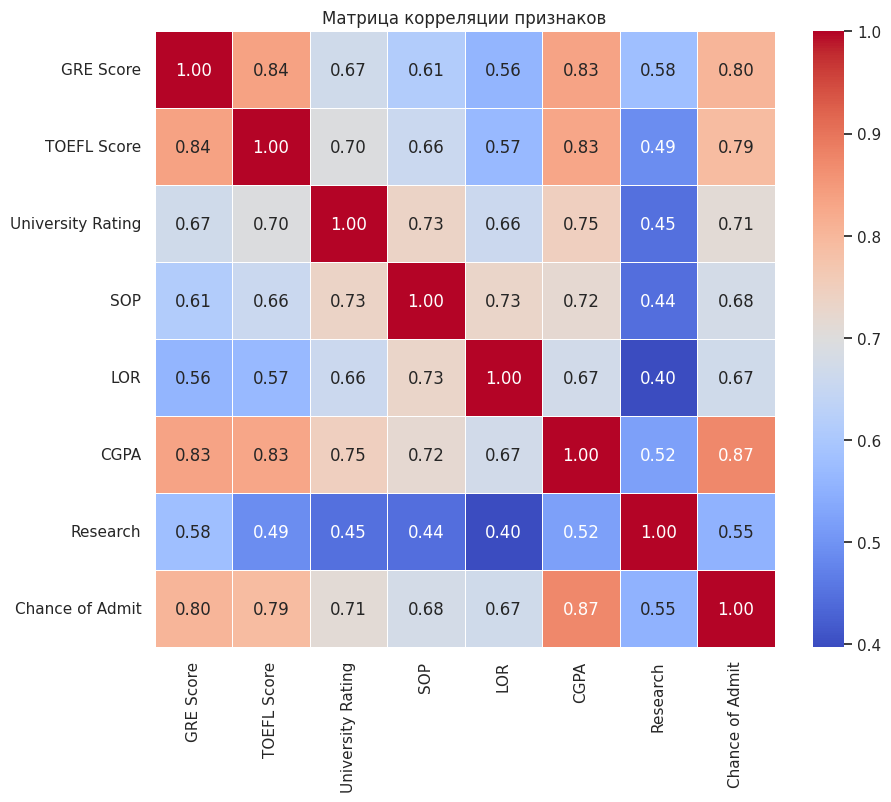

Корреляция признаков с шансом на поступление (Chance of Admit):
Chance of Admit      1.000000
CGPA                 0.873289
GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
Research             0.553202
Name: Chance of Admit, dtype: float64


In [7]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
title = plt.title("Матрица корреляции признаков")
plt.show()

# Вывод коэффициентов корреляции с целевой переменной
print("Корреляция признаков с шансом на поступление (Chance of Admit):")
print(correlation_matrix['Chance of Admit'].sort_values(ascending=False))

## 4. Визуализация: Скрипичная диаграмма (Violin Plot)

Построим Violin Plot для признака `CGPA` (средний балл), чтобы увидеть распределение данных и плотность.

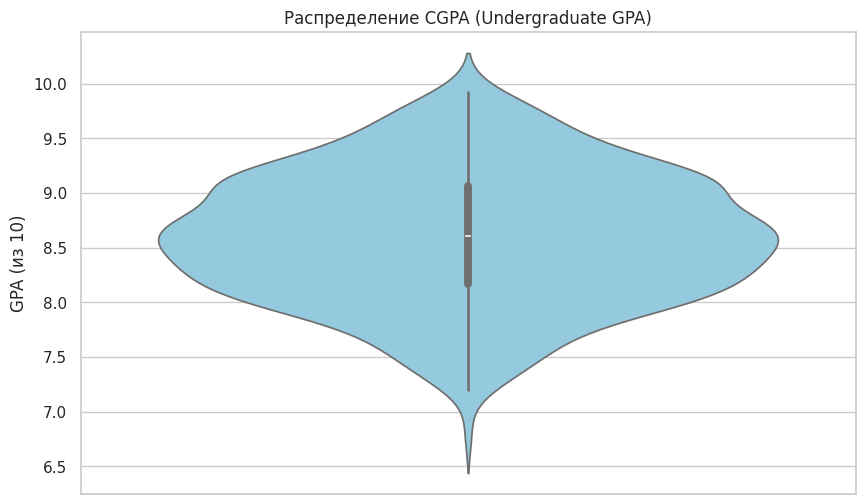

/tmp/ipykernel_2741/2551178796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Research', y='CGPA', data=df_cleaned, palette='Pastel1')


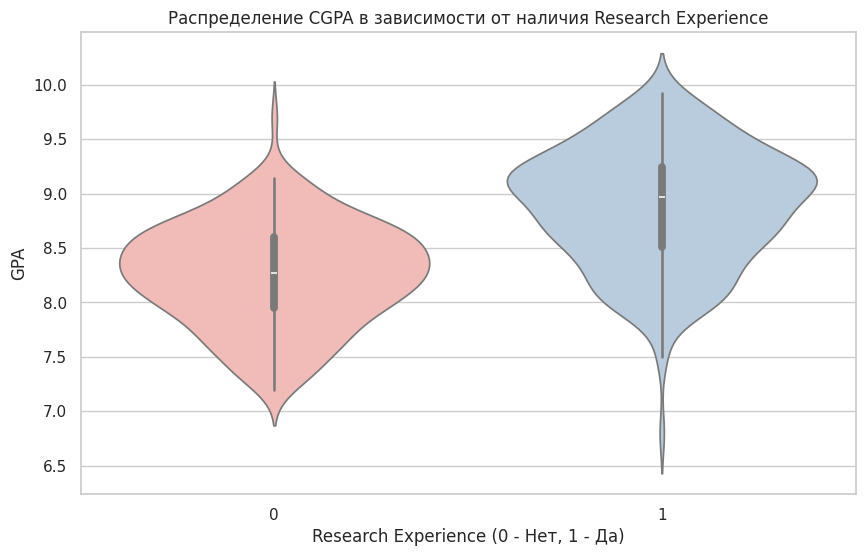

In [8]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df_cleaned['CGPA'], color="skyblue")
plt.title('Распределение CGPA (Undergraduate GPA)')
plt.ylabel('GPA (из 10)')
plt.show()

# Дополнительно: скрипичная диаграмма в разрезе опыта в исследованиях
plt.figure(figsize=(10, 6))
sns.violinplot(x='Research', y='CGPA', data=df_cleaned, palette='Pastel1')
plt.title('Распределение CGPA в зависимости от наличия Research Experience')
plt.xlabel('Research Experience (0 - Нет, 1 - Да)')
plt.ylabel('GPA')
plt.show()

## 5. Выводы

### Анализ корреляции:
1.  **Наиболее значимые признаки**: Признак `CGPA` (средний балл бакалавриата) имеет самую высокую корреляцию с целевой переменной `Chance of Admit` (**0.87**), за ним следуют показатели стандартизированных тестов: `GRE Score` (**0.80**) и `TOEFL Score` (**0.79**). Это указывает на то, что академическая успеваемость является определяющим фактором при поступлении.
2.  **Слабые признаки**: Признак `Research` (наличие опыта исследований) имеет наименьшую корреляцию с шансом на поступление (**0.55**). Тем не менее, визуализация (violin plot) показывает, что студенты с опытом исследований обычно обладают более высоким `CGPA`, что делает этот признак важным качественным разделителем.
3.  **Мультиколлинеарность**: Наблюдается очень высокая корреляция между `GRE Score`, `TOEFL Score` и `CGPA` (в диапазоне **0.83–0.84**). Это свидетельствует об избыточности данных, так как сильные кандидаты демонстрируют высокие результаты по всем метрикам одновременно, что следует учитывать при выборе методов регуляризации модели.

### Возможность построения моделей машинного обучения:
1.  **Тип задачи**: Набор данных предназначен для решения задачи регрессии (прогноз вероятности от 0 до 1). При необходимости задачу можно трансформировать в бинарную классификацию, установив порог прохождения (например, `Chance > 0.75`).
2.  **Перспективы**: Высокие коэффициенты линейной корреляции (большинство выше 0.7) позволяют ожидать отличных результатов от линейных моделей (например, **Linear Regression** или **Ridge/Lasso**). Данные демонстрируют явную линейную зависимость, что упрощает интерпретацию будущей модели.
3.  **Вклад признаков**:
    *   `CGPA`, `GRE` и `TOEFL` составят «базис» модели и обеспечат основную точность прогноза.
    *   `University Rating`, `SOP` (мотивационное письмо) и `LOR` (рекомендации) внесут дополнительный вклад, помогая модели различать кандидатов с одинаковыми тестовыми баллами.
    *   Данные достаточно чистые, без аномальных выбросов (что подтверждается симметричностью скрипичных диаграмм), что позволяет рассчитывать на высокую обобщающую способность модели и значение метрики **R² выше 0.80**.